# 基线

# 1.数据准备

## 1.1 观察Baseline因子

In [14]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [15]:
# 读取数据Baseline
df = pd.read_csv("../data/im_model.csv")
df.set_index('DateTime',inplace=True)
df.index = pd.to_datetime(df.index)
df = df.drop(df.index[-1])
df.index[:20]

DatetimeIndex(['2022-07-22 09:30:00', '2022-07-22 09:45:00',
               '2022-07-22 10:00:00', '2022-07-22 10:15:00',
               '2022-07-22 10:30:00', '2022-07-22 10:45:00',
               '2022-07-22 11:00:00', '2022-07-22 11:15:00',
               '2022-07-22 13:00:00', '2022-07-22 13:15:00',
               '2022-07-22 13:30:00', '2022-07-22 13:45:00',
               '2022-07-22 14:00:00', '2022-07-22 14:15:00',
               '2022-07-22 14:30:00', '2022-07-22 14:45:00',
               '2022-07-25 09:30:00', '2022-07-25 09:45:00',
               '2022-07-25 10:00:00', '2022-07-25 10:15:00'],
              dtype='datetime64[ns]', name='DateTime', freq=None)

In [16]:
df_test = df.loc['2024-09-30 14:45':'2025-10-16 14:30:00'].copy()
df_test

,factor,factor.1,factor.2,factor.3,factor.4,factor.5,factor.6,factor.7,factor.8,factor.9,factor.10,pos,close,net,datetime,y_list
DateTime,,,,,,,,,,,,,,,,
2024-09-30 14:45:00,-1.365602,-0.413196,-0.838961,-2.318327,-0.940603,2.720473,3.616264,2.935996,3.186278,2.145909,2.349189,0.104694,NaN,1.576809,NaN,0.000052
2024-10-08 09:30:00,-1.460120,-0.379620,-0.843615,-2.367487,-0.980415,2.661421,3.632956,2.861384,3.096539,2.113372,2.840353,0.029592,NaN,1.576803,NaN,0.000015
2024-10-08 09:45:00,-1.527722,-0.324669,-0.855313,-2.380995,-0.976971,2.605553,3.636333,2.791480,3.013310,2.082007,2.775981,0.007332,NaN,1.576621,NaN,0.000004
2024-10-08 10:00:00,-1.572882,-0.268139,-0.873667,-2.373098,-0.939083,2.552586,3.701813,2.859317,2.935735,2.051743,2.715302,0.010184,NaN,1.576597,NaN,0.000005
2024-10-08 10:15:00,-1.599381,-0.211521,-0.895544,-2.354792,-0.867106,2.502271,3.832620,2.987337,2.863187,2.022518,2.657970,0.034740,NaN,1.576691,NaN,0.000017
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-16 13:30:00,-0.919583,-3.244521,-0.231640,2.252919,-0.864984,-0.948788,1.445844,-1.133253,-0.427549,1.092825,-1.005340,-0.392371,NaN,1.679943,NaN,-0.000196
2025-10-16 13:45:00,-0.939802,-3.334555,-0.340903,2.223924,-0.818421,-1.064914,1.488923,-1.122245,-0.420936,1.082577,-0.996004,-0.404091,NaN,1.678384,NaN,-0.000202
2025-10-16 14:00:00,-0.958560,-3.400657,-0.429043,2.193687,-0.772578,-1.164578,1.531611,-1.111373,-0.414315,1.072448,-0.986762,-0.410923,NaN,1.678369,NaN,-0.000205


In [17]:
net_dif = np.diff(df_test['net'])
net_changes = np.insert(net_dif, 0, 0)
df_test["net_test"] = 1 + np.cumsum(net_changes)
df_test

,factor,factor.1,factor.2,factor.3,factor.4,factor.5,factor.6,factor.7,factor.8,factor.9,factor.10,pos,close,net,datetime,y_list,net_test
DateTime,,,,,,,,,,,,,,,,,
2024-09-30 14:45:00,-1.365602,-0.413196,-0.838961,-2.318327,-0.940603,2.720473,3.616264,2.935996,3.186278,2.145909,2.349189,0.104694,NaN,1.576809,NaN,0.000052,1.000000
2024-10-08 09:30:00,-1.460120,-0.379620,-0.843615,-2.367487,-0.980415,2.661421,3.632956,2.861384,3.096539,2.113372,2.840353,0.029592,NaN,1.576803,NaN,0.000015,0.999994
2024-10-08 09:45:00,-1.527722,-0.324669,-0.855313,-2.380995,-0.976971,2.605553,3.636333,2.791480,3.013310,2.082007,2.775981,0.007332,NaN,1.576621,NaN,0.000004,0.999812
2024-10-08 10:00:00,-1.572882,-0.268139,-0.873667,-2.373098,-0.939083,2.552586,3.701813,2.859317,2.935735,2.051743,2.715302,0.010184,NaN,1.576597,NaN,0.000005,0.999788
2024-10-08 10:15:00,-1.599381,-0.211521,-0.895544,-2.354792,-0.867106,2.502271,3.832620,2.987337,2.863187,2.022518,2.657970,0.034740,NaN,1.576691,NaN,0.000017,0.999882
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-16 13:30:00,-0.919583,-3.244521,-0.231640,2.252919,-0.864984,-0.948788,1.445844,-1.133253,-0.427549,1.092825,-1.005340,-0.392371,NaN,1.679943,NaN,-0.000196,1.103134
2025-10-16 13:45:00,-0.939802,-3.334555,-0.340903,2.223924,-0.818421,-1.064914,1.488923,-1.122245,-0.420936,1.082577,-0.996004,-0.404091,NaN,1.678384,NaN,-0.000202,1.101575
2025-10-16 14:00:00,-0.958560,-3.400657,-0.429043,2.193687,-0.772578,-1.164578,1.531611,-1.111373,-0.414315,1.072448,-0.986762,-0.410923,NaN,1.678369,NaN,-0.000205,1.101560


## 1.2 Baseline收益率

Text(0.5, 1.0, 'Baseline_model_net_values')

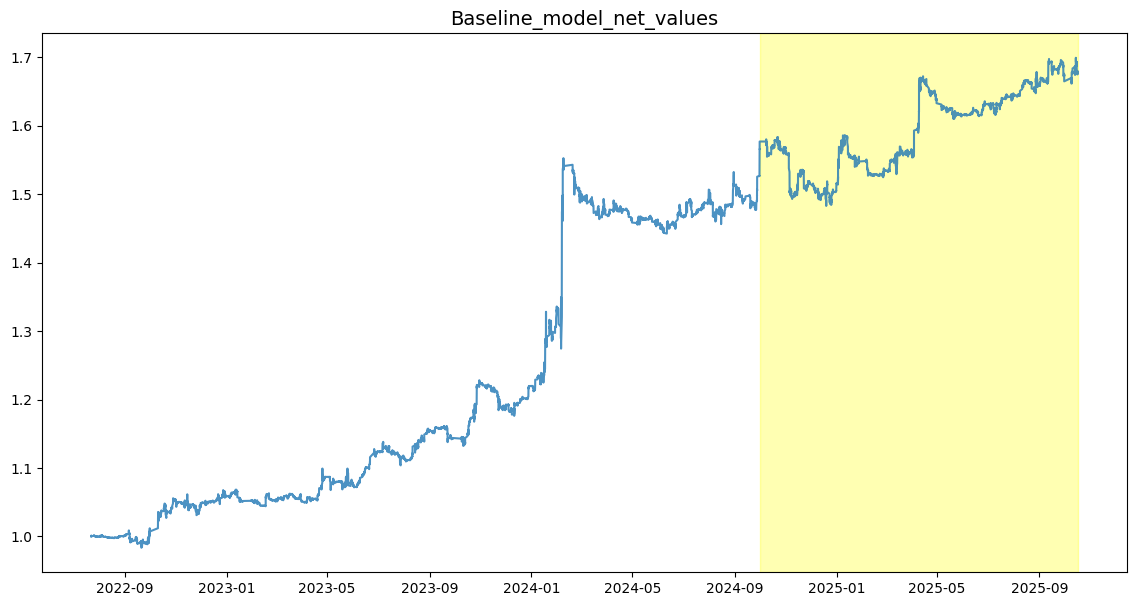

In [18]:
# 原始图像
start_mark = pd.to_datetime('2024-10-01 09:30:00')
end_mark = pd.to_datetime('2025-10-16 14:30:00')
time_delta = df.index[1] - df.index[0]
plot_dates = [df.index[0] - time_delta] + list(df.index)
net_values = np.insert(df["net"], 0, 1)
plt.figure(figsize=(14, 7), dpi=100)
plt.plot(plot_dates, net_values, color='#1f77b4', label='Market (Benchmark)', alpha=0.8)
plt.axvspan(start_mark, end_mark, color='yellow', alpha=0.3, label='Target Period')
plt.title("Baseline_model_net_values", fontsize=14)

## 1.3 测试切片

Text(0.5, 1.0, 'Baseline_model_net_values')

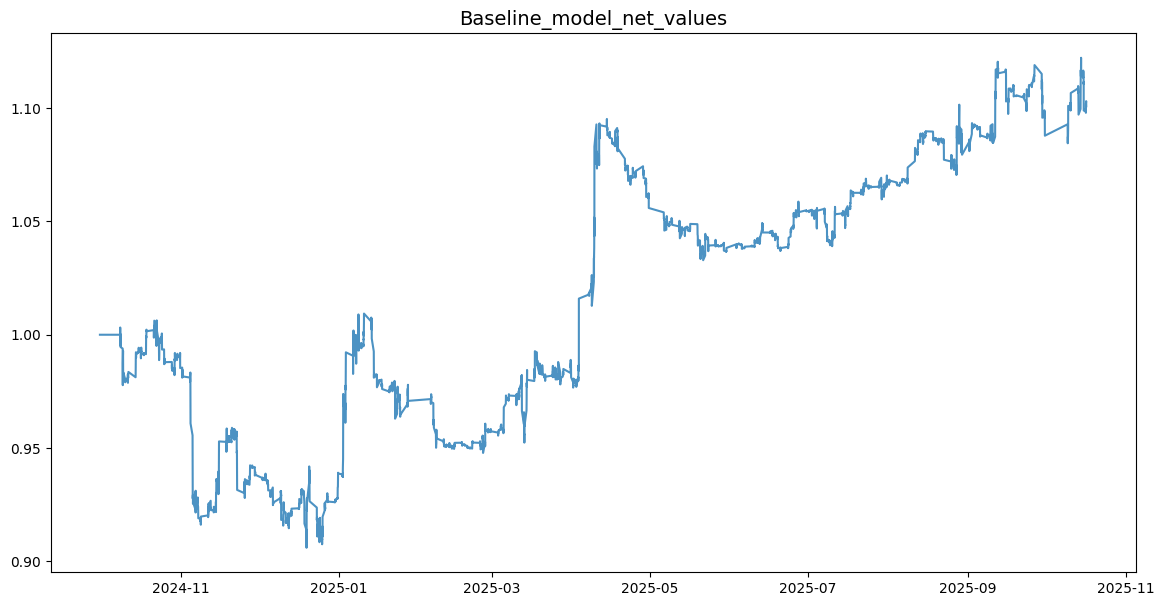

In [19]:
plt.figure(figsize=(14, 7), dpi=100)
plt.plot(df_test.index, df_test["net_test"], color='#1f77b4', label='Market (Benchmark)', alpha=0.8)
plt.title("Baseline_model_net_values", fontsize=14)

## 1.4 HMM/Market因子准备

In [20]:
df_HMM = pd.read_csv("../data/HMM_model_im.csv")
df_HMM.set_index('DateTime',inplace=True)
df_HMM.index = pd.to_datetime(df_HMM.index)
df_HMM_test = df_HMM.loc['2024-10-01 09:30':'2025-10-16 14:30:00'].copy()

In [21]:
df_HMM

,Unnamed: 0,day,open,high,low,close,vol,amount,twap,rsrs,...,slippage,f1,f2,f3,f4,f5,state,pos,HMM-net,market-net
DateTime,,,,,,,,,,,,,,,,,,,,,
2024-10-08 09:30:00,8528,2024/10/8,5283.599998,5283.599998,5245.399998,5277.399998,13110,16614235520,5281.599998,-6.430000e-27,...,1.894872e-07,4.218440,3.268524,0.112897,0.112897,0.007256,1,1.0,1.000675,1.000675
2024-10-08 09:45:00,8529,2024/10/8,5279.599998,5283.599998,5269.599998,5283.599998,2984,3781533480,5283.599998,7.234154e-26,...,1.892649e-07,-1.480111,3.436672,0.001174,0.114071,0.002653,3,1.0,0.975238,0.975238
2024-10-08 10:00:00,8530,2024/10/8,5283.599998,5283.599998,5147.199998,5149.199998,11814,14874581080,5259.319998,5.484912e-01,...,1.942049e-07,1.376021,0.795184,-0.025766,0.088305,0.026155,3,1.0,0.972829,0.972829
2024-10-08 10:15:00,8531,2024/10/8,5145.999998,5283.199998,5129.199998,5136.799998,12898,16182979600,5225.306665,6.792863e-01,...,1.946737e-07,0.087787,3.931438,-0.002411,0.085894,0.029582,3,1.0,0.976178,0.976178
2024-10-08 10:30:00,8532,2024/10/8,5135.399998,5162.399998,4839.599998,5153.999998,17691,21536400280,5050.279998,6.650614e-01,...,1.940241e-07,0.315984,4.518121,0.003343,0.089236,0.064570,3,1.0,0.943504,0.943504
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-20 13:45:00,11,2026/3/20,7660.000000,7666.200000,7642.000000,7643.800000,5447,8336630920,7652.946667,1.085567e+00,...,1.308250e-07,0.074489,-0.393088,-0.002091,-0.008338,0.003162,0,-1.0,1.694648,1.426132
2026-03-20 14:00:00,12,2026/3/20,7643.800000,7664.800000,7625.600000,7632.600000,6613,10109080200,7643.773333,1.033320e+00,...,1.310170e-07,0.193972,-0.676988,-0.001466,-0.016863,0.005127,2,-1.0,1.695172,1.425608
2026-03-20 14:15:00,13,2026/3/20,7633.000000,7643.800000,7619.400000,7628.600000,5162,7878171720,7631.746667,8.228993e-01,...,1.310857e-07,-0.247713,-0.534450,-0.000524,-0.010769,0.003197,2,-1.0,1.697951,1.422829


In [22]:
df_HMM_test["HMM_ret_array"] = df_HMM_test["HMM-net"].diff()
df_HMM_test["Market_ret_array"] = df_HMM_test["market-net"].diff()
df_HMM_test.loc[df_HMM_test.index[0], "HMM_ret_array"] = df_HMM_test["HMM-net"].iloc[0] - 1
df_HMM_test.loc[df_HMM_test.index[0], "Market_ret_array"] = df_HMM_test["market-net"].iloc[0] - 1

df_test["baseline_net_array"] = df_test["net_test"].diff()
df_test = df_test.iloc[1:].copy()
df_test

,factor,factor.1,factor.2,factor.3,factor.4,factor.5,factor.6,factor.7,factor.8,factor.9,factor.10,pos,close,net,datetime,y_list,net_test,baseline_net_array
DateTime,,,,,,,,,,,,,,,,,,
2024-10-08 09:30:00,-1.460120,-0.379620,-0.843615,-2.367487,-0.980415,2.661421,3.632956,2.861384,3.096539,2.113372,2.840353,0.029592,NaN,1.576803,NaN,0.000015,0.999994,-0.000006
2024-10-08 09:45:00,-1.527722,-0.324669,-0.855313,-2.380995,-0.976971,2.605553,3.636333,2.791480,3.013310,2.082007,2.775981,0.007332,NaN,1.576621,NaN,0.000004,0.999812,-0.000182
2024-10-08 10:00:00,-1.572882,-0.268139,-0.873667,-2.373098,-0.939083,2.552586,3.701813,2.859317,2.935735,2.051743,2.715302,0.010184,NaN,1.576597,NaN,0.000005,0.999788,-0.000024
2024-10-08 10:15:00,-1.599381,-0.211521,-0.895544,-2.354792,-0.867106,2.502271,3.832620,2.987337,2.863187,2.022518,2.657970,0.034740,NaN,1.576691,NaN,0.000017,0.999882,0.000094
2024-10-08 10:30:00,-1.588248,-0.156501,-0.919331,-2.319993,-0.767561,2.454387,4.049187,2.909433,2.795134,1.994271,2.603683,0.079808,NaN,1.574279,NaN,0.000040,0.997470,-0.002413
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-10-16 13:30:00,-0.919583,-3.244521,-0.231640,2.252919,-0.864984,-0.948788,1.445844,-1.133253,-0.427549,1.092825,-1.005340,-0.392371,NaN,1.679943,NaN,-0.000196,1.103134,0.000286
2025-10-16 13:45:00,-0.939802,-3.334555,-0.340903,2.223924,-0.818421,-1.064914,1.488923,-1.122245,-0.420936,1.082577,-0.996004,-0.404091,NaN,1.678384,NaN,-0.000202,1.101575,-0.001559
2025-10-16 14:00:00,-0.958560,-3.400657,-0.429043,2.193687,-0.772578,-1.164578,1.531611,-1.111373,-0.414315,1.072448,-0.986762,-0.410923,NaN,1.678369,NaN,-0.000205,1.101560,-0.000014


# 2.对比收益率

In [23]:
# 夏普计算
def calculate_sharpe(strat_ret, rf=0, periods=252):
    '''
    strat_ret: 策略收益率序列
    rf: 无风险利率 (年化)（市场的年化收益率）
    periods: 年度交易周期数 
    '''
    # 计算超额收益 (Daily Excess Return)
    excess_ret = strat_ret - (rf / periods)
    
    # 计算均值和标准差
    mean_ret = np.mean(excess_ret)
    std_ret = np.std(excess_ret)
    
    # 计算原始夏普 (非年化)
    if std_ret == 0:
        return 0
    sharpe = mean_ret / std_ret
    
    # 年化处理
    annual_sharpe = sharpe * np.sqrt(periods)
    
    return annual_sharpe

In [24]:
# 计算最大回撤
def calculate_mdd(cum_series):
    """
    计算净值曲线的最大回撤及其结束时间点
    """
    # 转换为 numpy 数组方便计算
    nav = np.array(cum_series)
    # 计算历史滚动最高点
    peaks = np.maximum.accumulate(nav)
    # 计算回撤序列 (当前值 / 历史最高值 - 1)
    drawdowns = (nav - peaks) / peaks
    # 找到最大回撤值（最小值）
    mdd_value = np.min(drawdowns)
    # 找到最大回撤发生的索引位置（即回撤结束/最低点的位置）
    mdd_idx = np.argmin(drawdowns)
    
    return mdd_value, mdd_idx

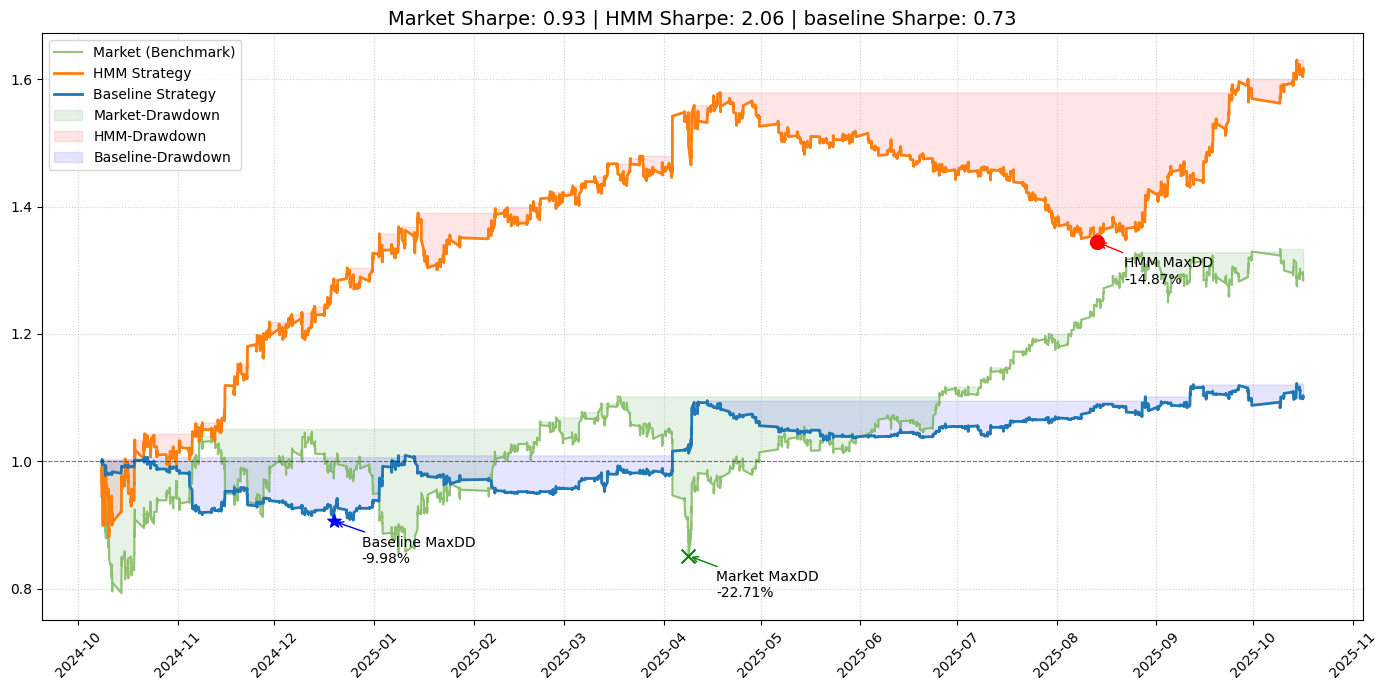

In [25]:
time_delta = df_test.index[1] - df_test.index[0]
plot_dates = [df_test.index[0] - time_delta] + list(df_test.index)

market_net = np.insert(df_HMM_test["market-net"], 0, 1)
HMM_net = np.insert(df_HMM_test["HMM-net"], 0, 1)
baseline_net = np.insert(df_test["net_test"], 0, 1)

market_ret = df_HMM_test['Market_ret_array'].groupby(df_HMM_test.index.date).apply(lambda x: np.prod(1 + x) - 1) # 复利计算收益率
HMM_ret = df_HMM_test['HMM_ret_array'].groupby(df_HMM_test.index.date).apply(lambda x: np.prod(1 + x) - 1) # 复利计算收益率
baseline_ret = df_test['baseline_net_array'].groupby(df_test.index.date).apply(lambda x: np.prod(1 + x) - 1) # 复利计算收益率

market_annual_sharpe = calculate_sharpe(market_ret)
HMM_annual_sharpe = calculate_sharpe(HMM_ret)
baseline_annual_sharpe = calculate_sharpe(baseline_ret)

m_mdd_val, m_mdd_idx = calculate_mdd(market_net)
h_mdd_val, h_mdd_idx = calculate_mdd(HMM_net)
b_mdd_val, b_mdd_idx = calculate_mdd(baseline_net)

m_mdd_date = plot_dates[m_mdd_idx]
h_mdd_date = plot_dates[h_mdd_idx]
b_mdd_date = plot_dates[b_mdd_idx]


plt.figure(figsize=(14, 7), dpi=100)
plt.plot(plot_dates, market_net, color='#7AB656', label='Market (Benchmark)', alpha=0.8)
plt.plot(plot_dates, HMM_net, color='#ff7f0e', label='HMM Strategy', linewidth=2)
plt.plot(plot_dates, baseline_net, color='#1f77b4', label='Baseline Strategy', linewidth=2)

market_peak = np.maximum.accumulate(market_net)
HMM_peak = np.maximum.accumulate(HMM_net)
baseline_peak = np.maximum.accumulate(baseline_net)

plt.fill_between(plot_dates, market_net, market_peak, color='green', alpha=0.1, label='Market-Drawdown')
plt.fill_between(plot_dates, HMM_net, HMM_peak, color='red', alpha=0.1, label='HMM-Drawdown')
plt.fill_between(plot_dates, baseline_net, baseline_peak, color='blue', alpha=0.1, label='Baseline-Drawdown')
plt.axhline(1, color='black', linestyle='--', linewidth=0.8, alpha=0.5)
    
# 标题与统计信息
plt.title(f"Market Sharpe: {market_annual_sharpe:.2f} | HMM Sharpe: {HMM_annual_sharpe:.2f} | baseline Sharpe: {baseline_annual_sharpe:.2f}", fontsize=14)
ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.xticks(rotation=45)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.scatter(m_mdd_date, market_net[m_mdd_idx], color='green', s=100, marker='x', 
        label=f'Market MaxDD: {m_mdd_val:.2%}', zorder=5)
plt.scatter(h_mdd_date, HMM_net[h_mdd_idx], color='red', s=100, marker='o', 
            label=f'HMM MaxDD: {h_mdd_val:.2%}', zorder=5)
plt.scatter(b_mdd_date, baseline_net[b_mdd_idx], color='blue', s=100, marker='*', 
            label=f'Baseline MaxDD: {b_mdd_val:.2%}', zorder=5)
            
# 标记最大回撤点
plt.annotate(f'Market MaxDD\n{m_mdd_val:.2%}', 
            xy=(m_mdd_date, market_net[m_mdd_idx]), 
            xytext=(20, -30), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='green'))
plt.annotate(f'HMM MaxDD\n{h_mdd_val:.2%}', 
            xy=(h_mdd_date, HMM_net[h_mdd_idx]), 
            xytext=(20, -30), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='red'))
plt.annotate(f'Baseline MaxDD\n{b_mdd_val:.2%}', 
            xy=(b_mdd_date, baseline_net[b_mdd_idx]), 
            xytext=(20, -30), textcoords='offset points',
            arrowprops=dict(arrowstyle='->', color='blue'))
plt.show()